# Test Forward Pass — ViT-L/14 (CLIP) Vision Encoder

## Mô tả task

**ViT-L/14 (CLIP)** là vision encoder được dùng trong pipeline BLIP-2 để trích xuất đặc trưng thị giác từ ảnh. Notebook này kiểm tra xem model hoạt động đúng bằng cách chạy một forward pass hoàn chỉnh.

---

### Kiến trúc ViT-L/14

```
Ảnh đầu vào [3 × 224 × 224]
        │
        ▼  Chia thành 16×16 patches → 196 patches  +  1 [CLS] token = 197 tokens (*)
   Patch Embedding  →  [197, 1024]
        │
        ▼  24 lớp Transformer (L = Large)
   Output hidden states  →  [197, 1024]
        │
        ├── last_hidden_state[0]   = CLS token  →  [1, 1024]  (đặc trưng toàn cục)
        └── last_hidden_state[1:]  = 196 patch tokens  →  [196, 1024]  (đặc trưng cục bộ)
```

> (*) Lưu ý: `CLIPVisionModel` của HuggingFace trả về **197 tokens** (không có token mở rộng). Trong `pre_extract_features.py` của dự án, output được lưu là **257 tokens** vì sử dụng một bản CLIP khác với patch size 14 trên 336px (CLIP ViT-L/14@336). Notebook này test model chuẩn ở 224px → 197 tokens.

---

### Đầu vào / Đầu ra

| | Mô tả | Shape |
|---|---|---|
| **Đầu vào** | Ảnh RGB sau preprocessing (normalize CLIP) | `[1, 3, 224, 224]` |
| **Đầu ra** `last_hidden_state` | Toàn bộ token embeddings | `[1, 197, 1024]` |
| **Đầu ra** `pooler_output` | CLS token sau pooling layer | `[1, 1024]` |

---

### Các bước xử lý

1. **Cài đặt & Import** thư viện cần thiết  
2. **Load model** `CLIPVisionModel` + `CLIPImageProcessor` từ HuggingFace  
3. **Chuẩn bị ảnh** đầu vào (tải ảnh mẫu)  
4. **Tiền xử lý** ảnh: resize → normalize → tensor  
5. **Forward pass** qua ViT-L/14  
6. **Kiểm tra output**: shape, thống kê, visualize feature norm theo từng patch

In [1]:
# ── Cài đặt thư viện nếu chưa có ──────────────────────────────────────────
# !pip install transformers torch torchvision pillow requests matplotlib -q

import sys
import warnings
warnings.filterwarnings("ignore")

import requests
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
from io import BytesIO
from transformers import CLIPImageProcessor, CLIPVisionModel

# Hằng số theo contracts.py
CLIP_FEATURE_DIM  = 1024   # chiều đặc trưng ViT-L/14
IMAGE_SIZE        = 224    # kích thước ảnh đầu vào

# Chọn device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"CUDA    : {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
Device  : cuda
CUDA    : Tesla T4


In [2]:
## ── Bước 2: Load model ──────────────────────────────────────────────────────
# CLIPVisionModel: chỉ lấy phần vision encoder, không có text encoder
# openai/clip-vit-large-patch14 = ViT-L/14 @ 224px

MODEL_NAME = "openai/clip-vit-large-patch14"

print(f"Đang tải model: {MODEL_NAME} ...")
processor = CLIPImageProcessor.from_pretrained(MODEL_NAME)
model     = CLIPVisionModel.from_pretrained(MODEL_NAME)
model     = model.to(DEVICE)
model.eval()   # tắt dropout / batchnorm training mode

# ── Thông tin kiến trúc ──────────────────────────────────────────────────────
cfg = model.config
print(f"\n{'='*50}")
print(f"Model          : {MODEL_NAME}")
print(f"Hidden size    : {cfg.hidden_size}")          # 1024
print(f"Num layers     : {cfg.num_hidden_layers}")    # 24
print(f"Num heads      : {cfg.num_attention_heads}")  # 16
print(f"Patch size     : {cfg.patch_size}")           # 14
print(f"Image size     : {cfg.image_size}")           # 224
n_patches = (cfg.image_size // cfg.patch_size) ** 2
print(f"Số patch tokens: {n_patches}  (+1 CLS = {n_patches + 1} tokens)")
print(f"Tổng tham số   : {sum(p.numel() for p in model.parameters()):,}")

Đang tải model: openai/clip-vit-large-patch14 ...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.embeddings.position_ids                    


Model          : openai/clip-vit-large-patch14
Hidden size    : 1024
Num layers     : 24
Num heads      : 16
Patch size     : 14
Image size     : 224
Số patch tokens: 256  (+1 CLS = 257 tokens)
Tổng tham số   : 303,179,776


Tải ảnh thành công từ COCO val2014
Kích thước ảnh gốc : (640, 360)  (W × H)
Mode               : RGB


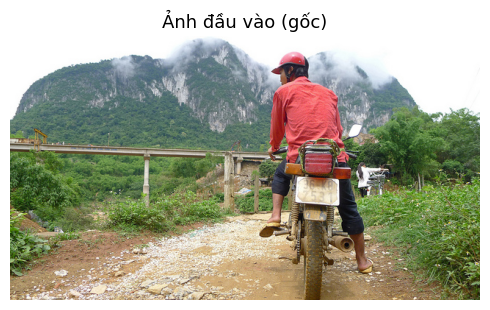

In [3]:
## ── Bước 3: Chuẩn bị ảnh đầu vào ───────────────────────────────────────────
# Tải một ảnh mẫu từ internet (ảnh chó ngồi trên bãi cỏ — điển hình cho VQA)
# Nếu không có mạng, thay bằng: image = Image.open("path/to/local.jpg")

IMG_URL = "http://images.cocodataset.org/val2014/COCO_val2014_000000391895.jpg"

try:
    response = requests.get(IMG_URL, timeout=10)
    response.raise_for_status()
    image_raw = Image.open(BytesIO(response.content)).convert("RGB")
    print(f"Tải ảnh thành công từ COCO val2014")
except Exception:
    # Fallback: tạo ảnh ngẫu nhiên nếu không có mạng
    print("Không tải được ảnh. Dùng ảnh ngẫu nhiên thay thế.")
    rng = np.random.default_rng(42)
    image_raw = Image.fromarray(
        (rng.random((IMAGE_SIZE, IMAGE_SIZE, 3)) * 255).astype(np.uint8)
    )

print(f"Kích thước ảnh gốc : {image_raw.size}  (W × H)")
print(f"Mode               : {image_raw.mode}")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(image_raw)
ax.set_title("Ảnh đầu vào (gốc)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

─── Thông tin tensor đầu vào ────────────────────────────
Shape  : [1, 3, 224, 224]
Dtype  : torch.float32
Device : cuda:0
Min    : -1.7339
Max    : 2.1459
Mean   : 0.3984


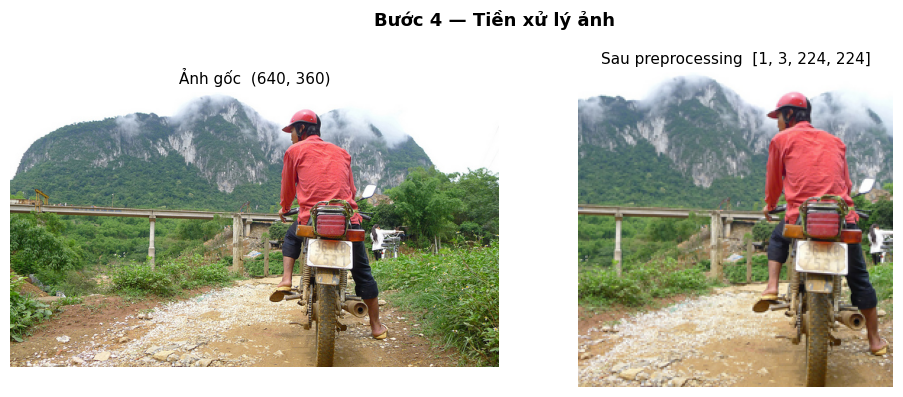

In [4]:
## ── Bước 4: Tiền xử lý ảnh (preprocessing) ─────────────────────────────────
# CLIPImageProcessor thực hiện:
#   1. Resize về IMAGE_SIZE × IMAGE_SIZE  (224 × 224)
#   2. Normalize với mean/std của CLIP:
#        mean = [0.48145466, 0.4578275, 0.40821073]
#        std  = [0.26862954, 0.26130258, 0.27577711]
#   3. Chuyển thành torch.Tensor [1, 3, 224, 224]

inputs = processor(images=image_raw, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(DEVICE)   # [1, 3, H, W]

print("─── Thông tin tensor đầu vào ────────────────────────────")
print(f"Shape  : {list(pixel_values.shape)}")
print(f"Dtype  : {pixel_values.dtype}")
print(f"Device : {pixel_values.device}")
print(f"Min    : {pixel_values.min():.4f}")
print(f"Max    : {pixel_values.max():.4f}")
print(f"Mean   : {pixel_values.mean():.4f}")

# Hiển thị ảnh sau khi resize (denormalize để vẽ lại)
mean = torch.tensor([0.48145466, 0.4578275,  0.40821073]).view(3, 1, 1)
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)
img_denorm = (pixel_values.cpu().squeeze(0) * std + mean).clamp(0, 1)
img_show   = img_denorm.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_raw)
axes[0].set_title(f"Ảnh gốc  {image_raw.size}", fontsize=11)
axes[0].axis("off")
axes[1].imshow(img_show)
axes[1].set_title(f"Sau preprocessing  [1, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]", fontsize=11)
axes[1].axis("off")
plt.suptitle("Bước 4 — Tiền xử lý ảnh", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
## ── Bước 5: Forward pass ────────────────────────────────────────────────────
# output_hidden_states=True để lấy hidden states của tất cả các lớp Transformer

with torch.no_grad():
    outputs = model(
        pixel_values=pixel_values,
        output_hidden_states=True,
        output_attentions=False,
    )

# ── Kiểm tra output ──────────────────────────────────────────────────────────
last_hidden = outputs.last_hidden_state   # [B, N_tokens, D]
pooler_out  = outputs.pooler_output       # [B, D]  — CLS sau projection + LayerNorm

B, N, D = last_hidden.shape

print("─── Kết quả forward pass ─────────────────────────────────")
print(f"last_hidden_state shape : {list(last_hidden.shape)}")
print(f"  → B={B} ảnh, N={N} tokens (1 CLS + {N-1} patches), D={D} chiều")
print(f"pooler_output shape     : {list(pooler_out.shape)}")
print()
print(f"CLS token (last_hidden_state[:, 0, :]):")
print(f"  min={last_hidden[0,0].min():.4f}  max={last_hidden[0,0].max():.4f}  "
      f"mean={last_hidden[0,0].mean():.4f}  norm={last_hidden[0,0].norm():.4f}")
print()
print(f"Patch tokens (last_hidden_state[:, 1:, :]):")
patch_norms = last_hidden[0, 1:, :].norm(dim=-1)  # [N-1]
print(f"  mean norm={patch_norms.mean():.4f}  "
      f"min={patch_norms.min():.4f}  max={patch_norms.max():.4f}")
print()
print(f"pooler_output (CLS projected):")
print(f"  min={pooler_out[0].min():.4f}  max={pooler_out[0].max():.4f}  "
      f"norm={pooler_out[0].norm():.4f}")

# Kiểm tra số hidden layers
n_layers = len(outputs.hidden_states)
print(f"\nSố hidden states (gồm embedding): {n_layers}  "
      f"(= 1 embedding + {n_layers - 1} transformer layers)")

─── Kết quả forward pass ─────────────────────────────────
last_hidden_state shape : [1, 257, 1024]
  → B=1 ảnh, N=257 tokens (1 CLS + 256 patches), D=1024 chiều
pooler_output shape     : [1, 1024]

CLS token (last_hidden_state[:, 0, :]):
  min=-3.5913  max=4.1110  mean=-0.0109  norm=15.9093

Patch tokens (last_hidden_state[:, 1:, :]):
  mean norm=25.1693  min=18.6642  max=216.7085

pooler_output (CLS projected):
  min=-11.5639  max=5.6961  norm=33.3382

Số hidden states (gồm embedding): 25  (= 1 embedding + 24 transformer layers)


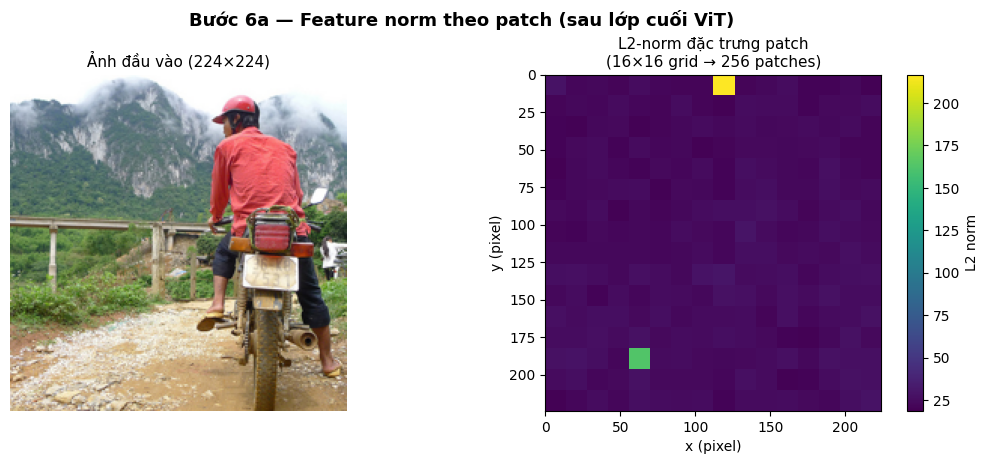

Patch grid  : 16 × 16 = 256 patches
Norm min    : 18.664
Norm max    : 216.708
Norm mean   : 25.169


In [6]:
## ── Bước 6a: Visualize feature norm theo từng patch ────────────────────────
# Mỗi patch token có một vector 1024-chiều.
# L2-norm của vector phản ánh "mức độ kích hoạt" tại vùng đó.
# Reshape từ [196] → [14, 14] để map lại lưới ảnh gốc.

PATCH_GRID = IMAGE_SIZE // model.config.patch_size   # 224 // 14 = 16

patch_tokens = last_hidden[0, 1:, :].cpu()           # [196, 1024]
patch_norms  = patch_tokens.norm(dim=-1)             # [196]
norm_map     = patch_norms.reshape(PATCH_GRID, PATCH_GRID).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ── Ảnh gốc đã resize ──────────────────────────────────────────────────────
axes[0].imshow(img_show)
axes[0].set_title(f"Ảnh đầu vào ({IMAGE_SIZE}×{IMAGE_SIZE})", fontsize=11)
axes[0].axis("off")

# ── Heatmap feature norm ───────────────────────────────────────────────────
im = axes[1].imshow(norm_map, cmap="viridis",
                    extent=[0, IMAGE_SIZE, IMAGE_SIZE, 0])
axes[1].set_title(f"L2-norm đặc trưng patch\n({PATCH_GRID}×{PATCH_GRID} grid → {PATCH_GRID**2} patches)", fontsize=11)
axes[1].set_xlabel("x (pixel)")
axes[1].set_ylabel("y (pixel)")
plt.colorbar(im, ax=axes[1], label="L2 norm")

plt.suptitle("Bước 6a — Feature norm theo patch (sau lớp cuối ViT)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Patch grid  : {PATCH_GRID} × {PATCH_GRID} = {PATCH_GRID**2} patches")
print(f"Norm min    : {norm_map.min():.3f}")
print(f"Norm max    : {norm_map.max():.3f}")
print(f"Norm mean   : {norm_map.mean():.3f}")

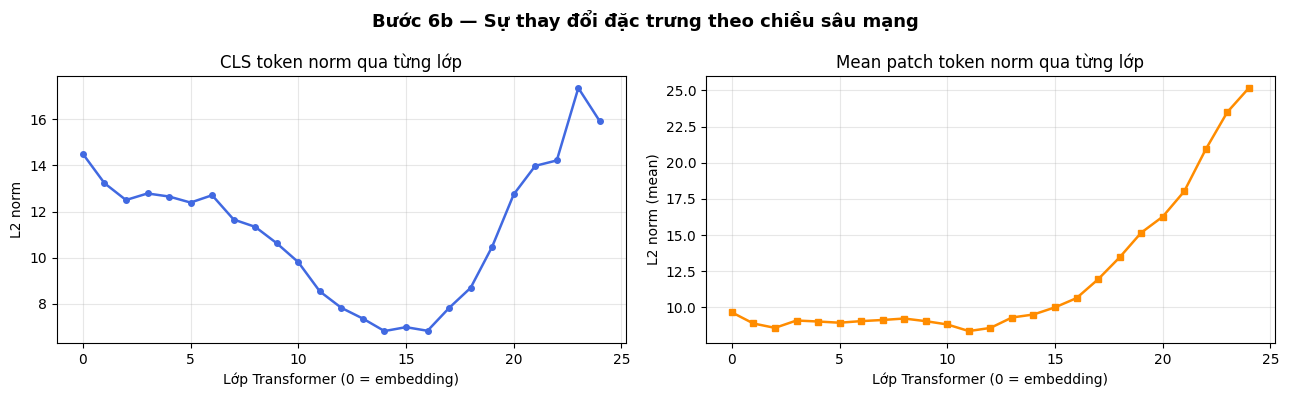

CLS norm tại embedding : 14.500
CLS norm tại lớp cuối  : 15.909   (= last_hidden_state[:, 0, :])


In [7]:
## ── Bước 6b: Phân tích hidden states qua từng lớp Transformer ──────────────
# Theo dõi CLS token norm qua 24 lớp → thấy đặc trưng được tinh chỉnh dần

hidden_states = outputs.hidden_states   # tuple: (embedding, layer1, ..., layer24)

cls_norms  = [hs[0, 0, :].norm().item()  for hs in hidden_states]   # norm CLS
mean_norms = [hs[0, 1:, :].norm(dim=-1).mean().item() for hs in hidden_states]  # mean patch norm

layers = list(range(len(hidden_states)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(layers, cls_norms, "o-", color="royalblue", linewidth=1.8, markersize=4)
axes[0].set_xlabel("Lớp Transformer (0 = embedding)")
axes[0].set_ylabel("L2 norm")
axes[0].set_title("CLS token norm qua từng lớp")
axes[0].grid(True, alpha=0.3)

axes[1].plot(layers, mean_norms, "s-", color="darkorange", linewidth=1.8, markersize=4)
axes[1].set_xlabel("Lớp Transformer (0 = embedding)")
axes[1].set_ylabel("L2 norm (mean)")
axes[1].set_title("Mean patch token norm qua từng lớp")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Bước 6b — Sự thay đổi đặc trưng theo chiều sâu mạng", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"CLS norm tại embedding : {cls_norms[0]:.3f}")
print(f"CLS norm tại lớp cuối  : {cls_norms[-1]:.3f}   (= last_hidden_state[:, 0, :])")

In [8]:
## ── Bước 7: Kiểm tra tương thích với pipeline dự án ─────────────────────────
# Trong pre_extract_features.py, output được lưu với shape (257, 1024) vì
# dùng model ViT-L/14 @ 336px (CLIP_PATCH_TOKENS=257 theo contracts.py).
# Ở đây dùng model 224px → 197 tokens. Xác nhận shape trước khi gắn vào Q-Former.

# ── Mô phỏng feature extraction ──────────────────────────────────────────────
features_all   = last_hidden[0]                        # [197, 1024]  tất cả tokens
features_patch = last_hidden[0, 1:, :]                 # [196, 1024]  chỉ patch tokens
features_cls   = last_hidden[0, 0, :].unsqueeze(0)     # [1,   1024]  chỉ CLS token
features_pool  = pooler_out[0].unsqueeze(0)            # [1,   1024]  pooler output

print("─── Tóm tắt output shape ────────────────────────────────────")
print(f"Tất cả tokens (CLS + patches) : {list(features_all.shape)}")
print(f"Chỉ patch tokens              : {list(features_patch.shape)}")
print(f"CLS token                     : {list(features_cls.shape)}")
print(f"Pooler output (projected CLS) : {list(features_pool.shape)}")
print()
print("─── Liên hệ với contracts.py ────────────────────────────────")
print(f"CLIP_FEATURE_DIM  = {CLIP_FEATURE_DIM}  → D={D}  {'✓ MATCH' if D == CLIP_FEATURE_DIM else '✗ KHÔNG KHỚP'}")
print(f"IMAGE_SIZE        = {IMAGE_SIZE}  → ảnh đầu vào {IMAGE_SIZE}×{IMAGE_SIZE}  ✓")
print()
print("─── Kiểm tra output hợp lệ cho Q-Former ─────────────────────")
# Q-Former cần: [B, N_visual_tokens, visual_dim]
# Đầu vào điển hình là toàn bộ patch tokens (không bao gồm CLS)
q_former_input = features_patch.unsqueeze(0)   # [1, 196, 1024]
assert q_former_input.dim() == 3, "Phải là 3D tensor [B, N, D]"
print(f"Shape đưa vào Q-Former : {list(q_former_input.shape)}  ✓")
print("\nForward pass kiểm tra HOÀN THÀNH!")

─── Tóm tắt output shape ────────────────────────────────────
Tất cả tokens (CLS + patches) : [257, 1024]
Chỉ patch tokens              : [256, 1024]
CLS token                     : [1, 1024]
Pooler output (projected CLS) : [1, 1024]

─── Liên hệ với contracts.py ────────────────────────────────
CLIP_FEATURE_DIM  = 1024  → D=1024  ✓ MATCH
IMAGE_SIZE        = 224  → ảnh đầu vào 224×224  ✓

─── Kiểm tra output hợp lệ cho Q-Former ─────────────────────
Shape đưa vào Q-Former : [1, 256, 1024]  ✓

Forward pass kiểm tra HOÀN THÀNH!
